<a href="https://colab.research.google.com/github/nlserikli-cpu/PET-Biomarker-Go-No-Go-Simulation-Simple-Signal-Analysis-/blob/main/pet_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


----------------------------
Case: Scenario A (likely drug effect)
Control mean: 98.45
Treatment mean: 84.97
Difference: 13.49
Effect score: 1.547
Confidence: 0.824
Decision: GO

----------------------------
Case: Scenario B (weak/no effect)
Control mean: 98.45
Treatment mean: 97.92
Difference: 0.53
Effect score: 0.057
Confidence: 0.514
Decision: NO-GO


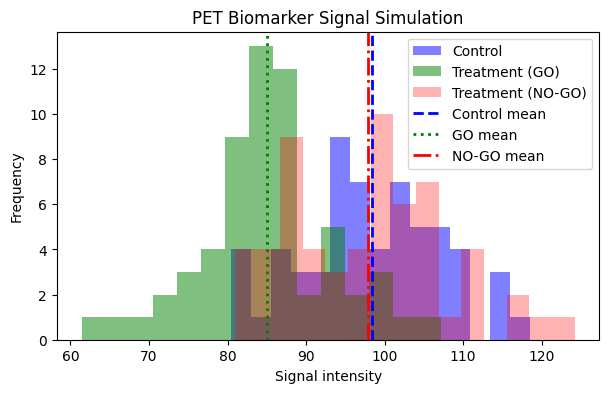

In [12]:
# PET Biomarker Go / No-Go Simulation (slightly expanded version)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# 1. Simulate PET biomarker data
# -----------------------------

n = 60

# baseline (control)
control = np.random.normal(100, 10, n)

# scenario A: moderate drug effect (GO case)
treatment_go = np.random.normal(85, 9, n)

# scenario B: weak / noisy effect (NO-GO case)
treatment_nogo = np.random.normal(97, 10, n)


# -----------------------------
# 2. simple helper function
# -----------------------------

def evaluate_group(control, treatment, label=""):
    c_mean = np.mean(control)
    t_mean = np.mean(treatment)

    diff = c_mean - t_mean

    # small issue: using std of both groups (not perfect but ok for demo)
    pooled_std = np.sqrt((np.std(control)**2 + np.std(treatment)**2) / 2)

    # effect size-ish metric (not strict Cohen’s d, simplified)
    effect = diff / pooled_std

    # confidence score (rough heuristic, not statistical)
    # maps effect size into 0–1 range
    confidence = 1 / (1 + np.exp(-effect))

    # decision rule
    threshold = 0.3

    if effect > threshold:
        decision = "GO"
    else:
        decision = "NO-GO"

    print("\n----------------------------")
    print("Case:", label)
    print("Control mean:", round(c_mean, 2))
    print("Treatment mean:", round(t_mean, 2))
    print("Difference:", round(diff, 2))
    print("Effect score:", round(effect, 3))
    print("Confidence:", round(confidence, 3))
    print("Decision:", decision)

    return effect, confidence, decision


# -----------------------------
# 3. evaluate both scenarios
# -----------------------------

e1, c1, d1 = evaluate_group(control, treatment_go, "Scenario A (likely drug effect)")
e2, c2, d2 = evaluate_group(control, treatment_nogo, "Scenario B (weak/no effect)")


# -----------------------------
# 4. visualization
# -----------------------------

plt.figure(figsize=(7,4))

plt.hist(control, bins=15, alpha=0.5, color="blue", label="Control")
plt.hist(treatment_go, bins=15, alpha=0.5, color="green", label="Treatment (GO)")
plt.hist(treatment_nogo, bins=15, alpha=0.3, color="red", label="Treatment (NO-GO)")

# means
control_mean = np.mean(control)
go_mean = np.mean(treatment_go)
nogo_mean = np.mean(treatment_nogo)

# dashed mean lines with distinct styles + colors
plt.axvline(control_mean, linestyle="--", linewidth=2, color="blue", label="Control mean")
plt.axvline(go_mean, linestyle=":", linewidth=2, color="green", label="GO mean")
plt.axvline(nogo_mean, linestyle="-.", linewidth=2, color="red", label="NO-GO mean")

plt.title("PET Biomarker Signal Simulation")
plt.xlabel("Signal intensity")
plt.ylabel("Frequency")
plt.legend()

plt.show()